In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## **Importing Dependencies**
---

In [ ]:
from preprocessing_utils_pipeline_universal import get_preprocessing_pipeline, get_house_features
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score

## **Fetching Datasets**
---

In [25]:
"""
1. The "SQL Power" Move (Filtering)
The beauty of using sqlite3 is that you don't have to load the entire dataset 
if you only want a specific part.
For example, if you wanted to look only at houses in a specific neighborhood or those 
built after the year 2000, you could do it directly in the query.
conn = sqlite3.connect('house_prices.db')

# Only pull houses with a Garage and more than 2 bathrooms
query = """
# SELECT * FROM train_records 
# WHERE GarageCars > 0 AND FullBath >= 2
"""
df_filtered = pd.read_sql(query, conn)
conn.close()
"""

# Connect to the database file you created with db_setup.py
conn = sqlite3.connect('house_prices.db')

# Pull the entire training table into a DataFrame
df_train = pd.read_sql("SELECT * FROM train_records", conn)

# Pull the test table
df_test = pd.read_sql("SELECT * FROM test_records", conn)

# Always close the connection when you're done loading
conn.close()

# Check the results
print(f"Dataset loaded! Train shape: {df_train.shape}")
print(df_train.info())
df_train.head()

Dataset loaded! Train shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


## **Exploratory Data Analysis (EDA)**
---

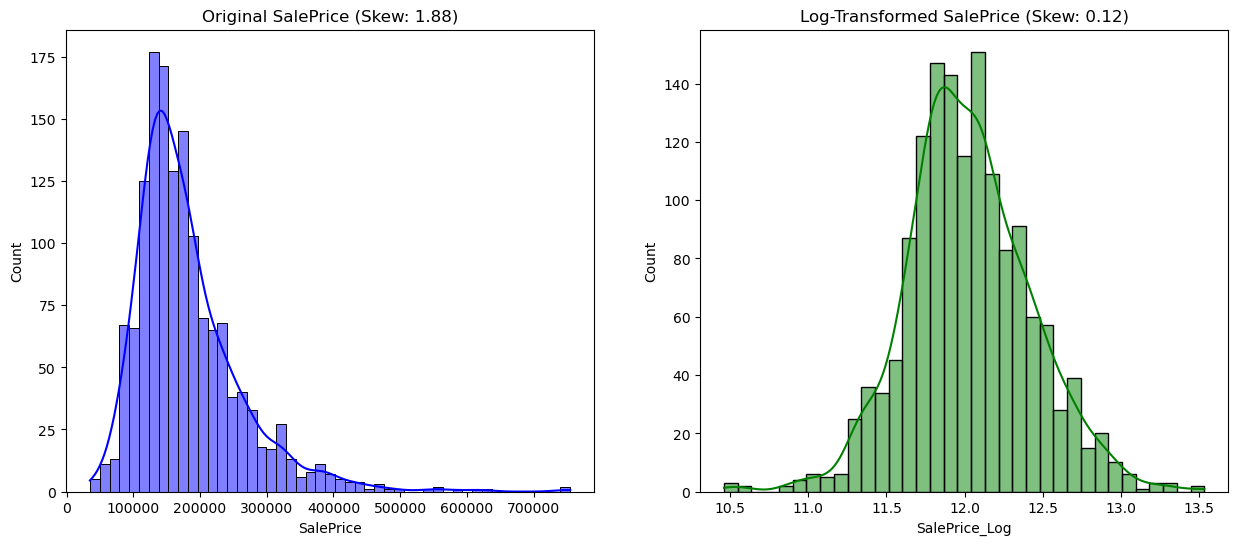

In [26]:
# Apply the log transformation to the target variable
df_train['SalePrice_Log'] = np.log1p(df_train['SalePrice'])

# Visualize the 'Before' and 'After' side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original
sns.histplot(df_train['SalePrice'], kde=True, ax=ax1, color='blue')
ax1.set_title(f"Original SalePrice (Skew: {df_train['SalePrice'].skew():.2f})")

# Transformed
sns.histplot(df_train['SalePrice_Log'], kde=True, ax=ax2, color='green')
ax2.set_title(f"Log-Transformed SalePrice (Skew: {df_train['SalePrice_Log'].skew():.2f})")

plt.show()

In [33]:
# Find which numeric features move the price the most
# We select only numeric columns to calculate correlation
# And create distribution plots for all numeric features.
numeric_df = df_train.select_dtypes(include=[np.number])
numeric_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,SalePrice_Log
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,61,0,0,0,0,0,2,2008,208500,12.247699
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,0,0,5,2007,181500,12.109016
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,42,0,0,0,0,0,9,2008,223500,12.317171
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,35,272,0,0,0,0,2,2006,140000,11.849405
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,84,0,0,0,0,0,12,2008,250000,12.429220


array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

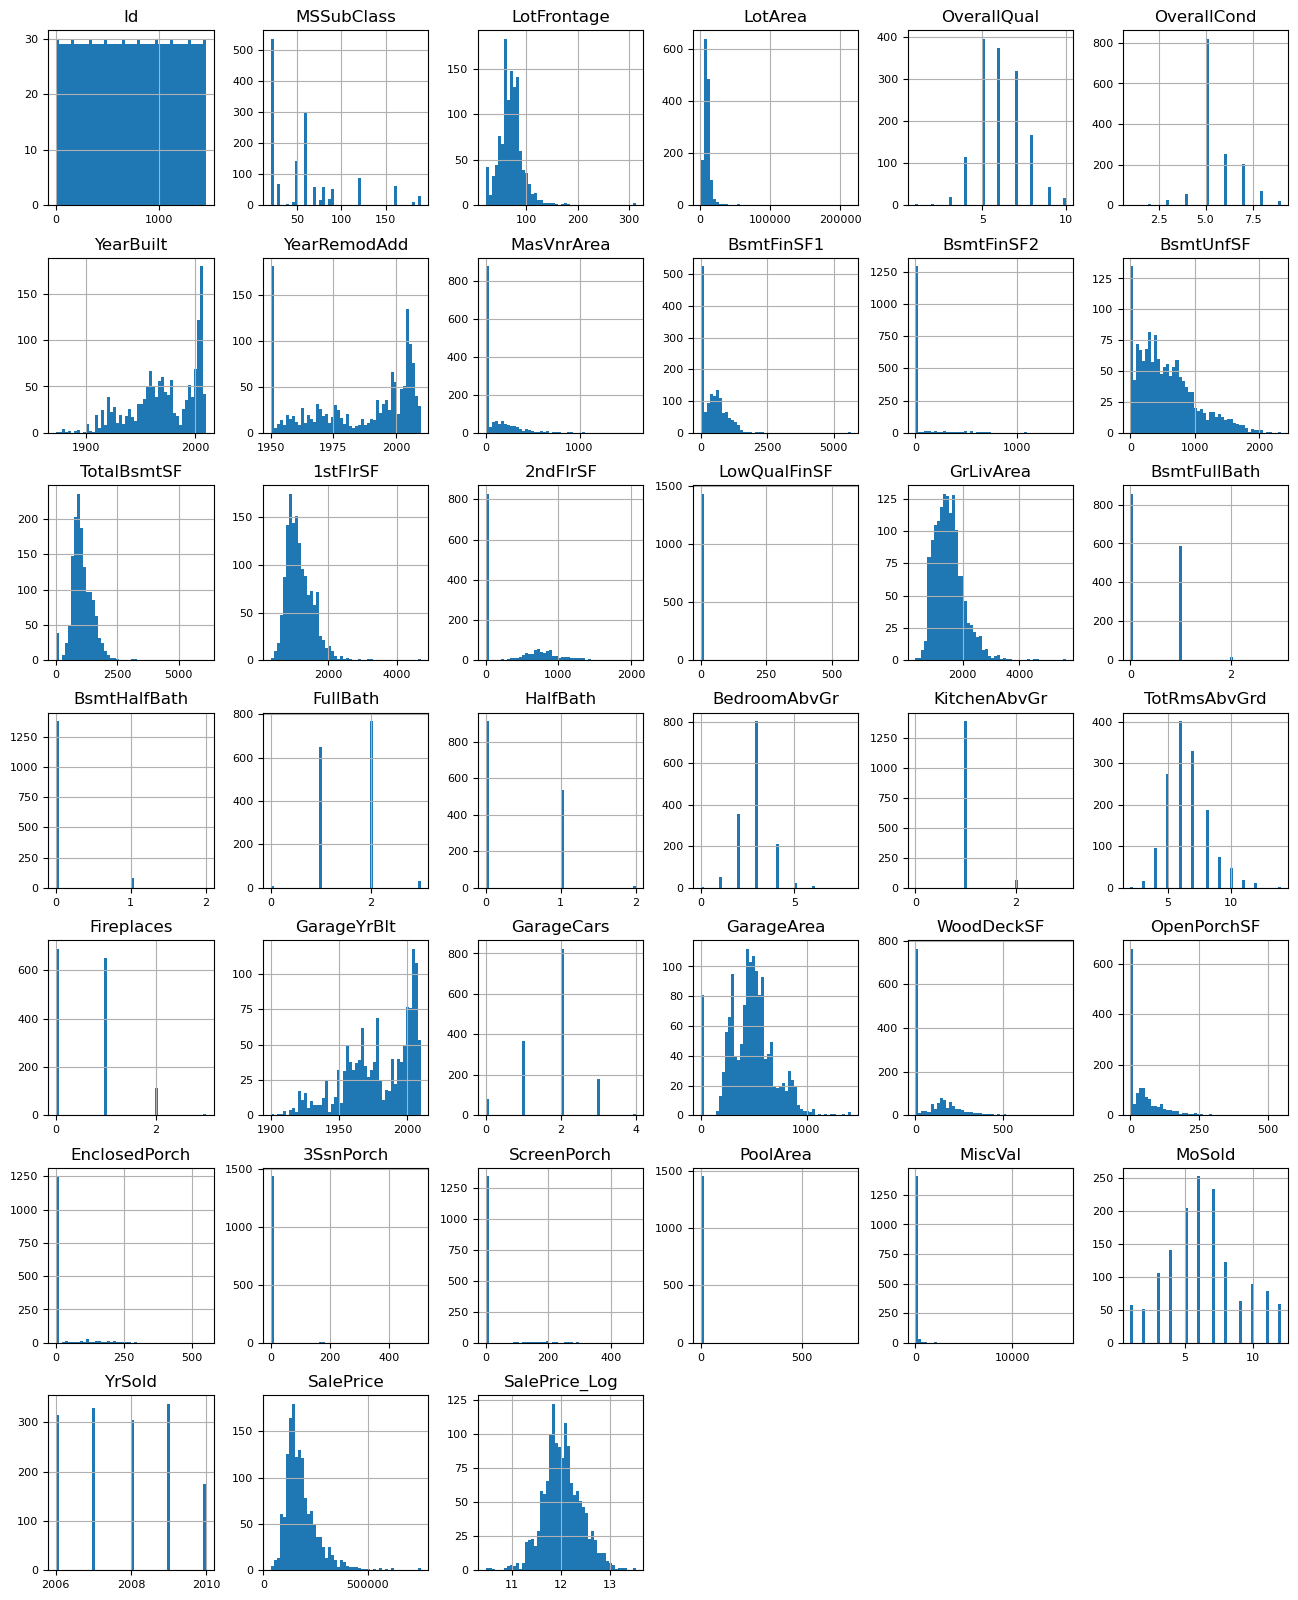

In [34]:
# Visualize the distribution of all numeric features
numeric_df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [36]:
correlations = numeric_df.corr()['SalePrice_Log'].sort_values(ascending=False)

print("Top 5 Features most correlated with Price:")
print(correlations.head(7)) # Top 5 + SalePrice and SalePrice_Log itself

Top 5 Features most correlated with Price:
SalePrice_Log    1.000000
SalePrice        0.948374
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
Name: SalePrice_Log, dtype: float64


In [41]:
# Calculate percentage of missing values for each column
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with the most Missing Values:\n{missing.head(10)}\n")

missing_pct = (missing / len(df_train)) * 100

print("Columns with the most Missing Values (%):")
print(missing_pct.head(10))

Columns with the most Missing Values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

Columns with the most Missing Values (%):
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
dtype: float64


In [ ]:
# 1. Handle Categorical "NA" by filling with "None"
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'MasVnrType'
]

for col in none_cols:
    df_train[col] = df_train[col].fillna("None")
    df_test[col] = df_test[col].fillna("None")

# 2. Handle Numeric Garage columns by filling with 0
df_train['GarageYrBlt'] = df_train['GarageYrBlt'].fillna(0)
df_test['GarageYrBlt'] = df_test['GarageYrBlt'].fillna(0)

# 3. Handle LotFrontage (Special Case: Impute by Neighborhood)
# We fill missing LotFrontage with the median of its Neighborhood i.e. "the typical LotFrontage for that neighborhood"
# Group by Neighborhood and fill missing LotFrontage values with its neighborhood median
df_train["LotFrontage"] = df_train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)
df_test["LotFrontage"] = df_test.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

print("Important missing values have been handled.")

Important missing values have been handled.


## **Preparing the Datasets**
---

In [44]:
# 1. Define the target (y) using the Log-Transformed price
y_train = df_train["SalePrice_Log"]

# 2. Define the features (X) by dropping the target and Id columns (and any other non-feature columns)
X_train = df_train.drop(["SalePrice", "SalePrice_Log", "Id"], axis=1)

# 3. Prepare X_test (must have the exact same columns as X_train)
X_test = df_test.drop(["Id"], axis=1)

print(f"Split Complete!")
print(f"Feature count: {X_train.shape[1]}") # Should be 79

Split Complete!
Feature count: 79


## **Preprocessing the Datasets**
---

In [ ]:
# Step 1: Specific House Engineering
X_train_engineered = get_house_features(X_train)
X_test_engineered = get_house_features(X_test)

# Choose your model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Pass both the data (for column detection) AND the model to the pipeline
rf_pipeline = get_preprocessing_pipeline(X_train_engineered, model)

# Now you can fit the entire thing
rf_pipeline.fit(X_train_engineered, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'BsmtQual', 'BsmtCond', 'BsmtFinSF1', 'BsmtFinSF2', 'Bsm...
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
       'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
def run_hyperparameter_tuning(X, y):
    """
    EXPERIMENTAL SECTION: 
    This function contains the GridSearchCV logic used to find the best parameters.
    It is kept here for documentation purposes but is not called during the 
    production run to save time.
    """

    # --- 1. LOGISTIC REGRESSION TUNING ---
    log_pipeline = get_preprocessing_pipeline(X, LogisticRegression(random_state=42))
    log_grid = {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'lbfgs'],
        'model__max_iter': [100, 200, 500]
    }
    grid_search_log = GridSearchCV(log_pipeline, log_grid, cv=5, scoring='accuracy', n_jobs=-1)
    # grid_search_log.fit(X, y) # Commented out to prevent accidental runs

    # --- 2. RANDOM FOREST TUNING ---
    rf_pipeline = get_preprocessing_pipeline(X, RandomForestClassifier(random_state=42))
    rf_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [5, 8, 10],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
    grid_search_rf = GridSearchCV(rf_pipeline, rf_grid, cv=5, scoring='accuracy', n_jobs=-1)
    # grid_search_rf.fit(X, y)

    # --- 3. XGBOOST TUNING ---
    xgb_pipeline = get_preprocessing_pipeline(X, XGBClassifier(random_state=42)) 
    xgb_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0]
    }
    grid_search_xgb = GridSearchCV(xgb_pipeline, xgb_grid, cv=5, scoring='accuracy', n_jobs=-1)
    # grid_search_xgb.fit(X, y)

# NOTE: We do not call run_hyperparameter_tuning() here.
# This keeps the code visible but inactive.